<a href="https://colab.research.google.com/github/josephineabioye/msc-skincare-reaction-prediction/blob/main/notebooks/04_modelling_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata, drive
import os

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USERNAME = 'josephineabioye'
REPO_NAME = 'msc-skincare-reaction-prediction'

if not os.path.exists(REPO_NAME):
    !git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
    %cd {REPO_NAME}
else:
    %cd {REPO_NAME}
    !git pull

!git config user.email "josephineabioye@yahoo.com"
!git config user.name "Josephine Abioye"

drive.mount('/content/drive', force_remount=False)

DRIVE_PROJECT = '/content/drive/MyDrive/msc-skincare-project'
DATA_RAW = f'{DRIVE_PROJECT}/data/raw'
DATA_PROCESSED = f'{DRIVE_PROJECT}/data/processed'

print(f"Working in: {os.getcwd()}")

Cloning into 'msc-skincare-reaction-prediction'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 123 (delta 66), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 210.76 KiB | 5.27 MiB/s, done.
Resolving deltas: 100% (66/66), done.
/content/msc-skincare-reaction-prediction
Mounted at /content/drive
Working in: /content/msc-skincare-reaction-prediction


Notebook Overview

In [5]:
# filters the dataset to skincare products, removes multi-product entries, cleans and standardises the ingredient names,
# and create a set of unique ingredients for each product.
import pandas as pd, ast, re

# Load the product information and keep only skincare products
products = pd.read_csv(f"{DATA_RAW}/product_info.csv")
skincare = products[products['primary_category'] == 'Skincare'].copy()

# Remove multi-product entries
has_ingredients = skincare[skincare['ingredients'].notna()]
is_multivariant = has_ingredients['ingredients'].str.contains(":'", regex=False)
single_products = has_ingredients[~is_multivariant].copy()
print("Single-product entries:", single_products.shape[0])

# Clean and convert each product's ingredient list into a set of ingredients
def parse_ingredients(raw):
    try:
        parts = ast.literal_eval(raw)
    except Exception:
        parts = [str(raw)]
    if not isinstance(parts, list):
        parts = [str(parts)]
    text = " , ".join(str(p) for p in parts)
    toks = set()
    for t in text.split(","):
        t = re.sub(r"\(.*?\)", " ", t)                # Remove additional notes in brackets
        t = re.sub(r"[^A-Za-z0-9\- ]", " ", t)        # Remove unnecessary punctuation
        t = re.sub(r"\s+", " ", t).strip().lower()    # Standardise spacing and convert ingredient names to lowercase
        if len(t) > 1:
            toks.add(t)
    return toks or None

# Apply the ingredient cleaning to all single-product entries
single_products["ing_set"] = single_products["ingredients"].apply(parse_ingredients)

# Keep products where the ingredient list was successfully parsed
prod = single_products[single_products["ing_set"].notna()].copy()

print("products with parsed ingredients:", prod["product_id"].nunique())
print("unique ingredient tokens:", len(set().union(*prod["ing_set"])))

Single-product entries: 2069
products with parsed ingredients: 2069
unique ingredient tokens: 5468


In [8]:
# keep ingredients appearing in at least five products, count ingredient frequency, converts the product ingredients into a sparse multi-hot feature matrix,
# and links the ingredient features to the labelled reviews.
from collections import Counter
import numpy as np
from scipy import sparse

# 1. Ingredient frequency (how many products each ingredient appears in)
df_counter = Counter()
for s in prod["ing_set"]:
    df_counter.update(s)

MIN_DF = 5   # Keep ingredients that appear in at least 5 products

vocab = sorted(ing for ing, c in df_counter.items() if c >= MIN_DF)
vocab_index = {ing: i for i, ing in enumerate(vocab)}
print(f"features kept: {len(vocab)} of {len(df_counter)} (MIN_DF={MIN_DF})")

# 2. Create a product-level multi-hot sparse matrix that shows whether each ingredient
# is present in each product.
prod = prod.reset_index(drop=True)
rows, cols = [], []
for r, s in enumerate(prod["ing_set"]):
    for ing in s:
        j = vocab_index.get(ing)
        if j is not None:
            rows.append(r); cols.append(j)
X_prod = sparse.csr_matrix((np.ones(len(rows), dtype=np.int8), (rows, cols)),
                           shape=(len(prod), len(vocab)))

# Map each product ID and its row in the ingredient matrix
pid_to_row = {pid: r for r, pid in enumerate(prod["product_id"])}

# 3. join to the labelled reviews (inner join on product_id) and keep the fields needed for the analysis
reviews = pd.read_parquet(f"{DATA_PROCESSED}/skincare_reviews_labelled.parquet",
                          columns=["product_id", "reaction_label", "skin_type", "skin_tone"])

# Keep only reviews for products that have usable ingredient information
reviews = reviews[reviews["product_id"].isin(pid_to_row)].reset_index(drop=True)

# Match each review to the corresponding product row in the ingredient matrix
row_idx = reviews["product_id"].map(pid_to_row).to_numpy()
X = X_prod[row_idx]                              # review-level ingredient matrix using the product ingredients
y = reviews["reaction_label"].to_numpy()         # Store the reaction labels for the reviews

# Keep product IDs so that reviews from the same product can be kept together or the by-product split
groups = reviews["product_id"].to_numpy()

print("reviews kept:", X.shape[0], "| features:", X.shape[1])
print("positives:", int(y.sum()), f"({y.mean():.3f})")

features kept: 1710 of 5468 (MIN_DF=5)
reviews kept: 1040578 | features: 1710
positives: 115466 (0.111)


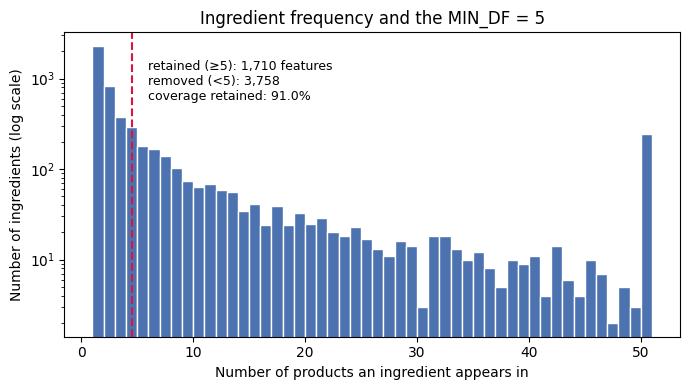

retained 1,710 | removed 3,758 | coverage 91.0%


In [12]:
# Graphical representation of ingredient occurrences retained after filtering
import matplotlib.pyplot as plt
import numpy as np

dfvals   = np.array(list(df_counter.values()))
kept     = int((dfvals >= MIN_DF).sum())
removed  = int((dfvals <  MIN_DF).sum())
coverage = dfvals[dfvals >= MIN_DF].sum() / dfvals.sum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.clip(dfvals, 1, 50), bins=range(1, 52), color="#4C72B0", edgecolor="white")
ax.axvline(MIN_DF - 0.5, color="crimson", linestyle="--", linewidth=1.5)
ax.set_yscale("log")
ax.set_xlabel("Number of products an ingredient appears in")
ax.set_ylabel("Number of ingredients (log scale)")
ax.set_title(f"Ingredient frequency and the MIN_DF = {MIN_DF}")
ax.text(MIN_DF + 1, ax.get_ylim()[1] * 0.5,
        f"retained (≥{MIN_DF}): {kept:,} features\nremoved (<{MIN_DF}): {removed:,}\ncoverage retained: {coverage:.1%}",
        fontsize=9, va="top")
plt.tight_layout()
plt.savefig(f"{DATA_PROCESSED}/min_df_cut_fig.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"retained {kept:,} | removed {removed:,} | coverage {coverage:.1%}")

In [15]:
#Split to train and test sets by product using 80%(Train) 20%(Test)
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("train:", X_train.shape[0], "| test:", X_test.shape[0])
print("train positive reactions:", round(y_train.mean(), 3), "| test positive reactions:", round(y_test.mean(), 3))
assert set(groups[train_idx]).isdisjoint(set(groups[test_idx]))
print("no product appears in both train and test")

train: 832205 | test: 208373
train positive reactions: 0.111 | test positive reactions: 0.112
no product appears in both train and test


In [26]:
# Convert allergens from Warshaw et al. (2015) to their INCI ingredient tokens, check which are present in the product dataset.
# The identified ingredients form the BLACKLIST used in the reaction-labelling analysis.
import pandas as pd

# Warshaw et al. (2015) allergens -> INCI ingredient tokens
warshaw_inci = {
    "fragrance mix I":        ["eugenol","geraniol","hydroxycitronellal","cinnamal",
                               "cinnamyl alcohol","isoeugenol","amyl cinnamal","evernia prunastri"],
    "MCI/MI":                 ["methylisothiazolinone","methylchloroisothiazolinone"],
    "lanolin alcohol":        ["lanolin","lanolin alcohol"],
    "cinnamic aldehyde":      ["cinnamal"],
    "paraben mix":            ["methylparaben","ethylparaben","propylparaben","butylparaben","isobutylparaben"],
    "glutaral":               ["glutaral","glutaraldehyde"],
    "formaldehyde-releasers": ["formaldehyde","quaternium-15","diazolidinyl urea",
                               "imidazolidinyl urea","dmdm hydantoin","2-bromo-2-nitropropane-1,3-diol"],
}

rows = []
BLACKLIST = set()
for allergen, incis in warshaw_inci.items():
    present = {i: df_counter.get(i, 0) for i in incis if df_counter.get(i, 0) > 0}
    absent  = [i for i in incis if df_counter.get(i, 0) == 0]
    BLACKLIST |= set(present)
    rows.append({
        "Warshaw allergen": allergen,
        "INCI tokens & (product count)": ", ".join(f"{k} ({v})" for k, v in present.items()) or "—",
        "Absent from dataset": ", ".join(absent) or "—",
    })

blacklist_table = pd.DataFrame(rows)

print("Final BLACKLIST size:", len(BLACKLIST))
print("BLACKLIST:", sorted(BLACKLIST), "\n")
blacklist_table

Final BLACKLIST size: 16
BLACKLIST: ['amyl cinnamal', 'butylparaben', 'cinnamal', 'cinnamyl alcohol', 'diazolidinyl urea', 'ethylparaben', 'eugenol', 'geraniol', 'glutaral', 'hydroxycitronellal', 'lanolin', 'lanolin alcohol', 'methylchloroisothiazolinone', 'methylisothiazolinone', 'methylparaben', 'propylparaben'] 



,Warshaw allergen,INCI tokens & (product count),Absent from dataset
0,fragrance mix I,"eugenol (40), geraniol (261), hydroxycitronell...","isoeugenol, evernia prunastri"
1,MCI/MI,"methylisothiazolinone (10), methylchloroisothi...",—
2,lanolin alcohol,"lanolin (2), lanolin alcohol (8)",—
3,cinnamic aldehyde,cinnamal (3),—
4,paraben mix,"methylparaben (52), ethylparaben (9), propylpa...",isobutylparaben
5,glutaral,glutaral (2),glutaraldehyde
6,formaldehyde-releasers,diazolidinyl urea (8),"formaldehyde, quaternium-15, imidazolidinyl ur..."


In [28]:
# Apply allergen blacklist, tests it on the held-out reviews, and
# evaluates how well it predicts the manually assigned reaction labels using accuracy, precision, recall, F1, AUC-ROC, and a confusion matrix.
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

# positive if ingredients intersect the blacklist
prod["bl_hit"] = prod["ing_set"].apply(lambda s: int(len(s & BLACKLIST) > 0))
pid_to_hit = dict(zip(prod["product_id"], prod["bl_hit"]))
bl_pred_all = reviews["product_id"].map(pid_to_hit).to_numpy()

y_pred = bl_pred_all[test_idx]
y_true = y_test

print("Blacklist flags", f"{prod['bl_hit'].mean():.1%}", "of products")
print("predicted-positive share of (test):", round(y_pred.mean(), 3))
print()
print("Accuracy :", round(accuracy_score(y_true, y_pred), 3),
      "| majority-class baseline:", round(1 - y_true.mean(), 3))
print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_true, y_pred, zero_division=0), 3))
print("F1       :", round(f1_score(y_true, y_pred, zero_division=0), 3))
print("AUC-ROC  :", round(roc_auc_score(y_true, y_pred), 3), "(hard rule, so limited)")
print("\nConfusion matrix [rows = true 0/1, cols = pred 0/1]:")
print(confusion_matrix(y_true, y_pred))

Blacklist flags 17.2% of products
predicted-positive share of (test): 0.157

Accuracy : 0.762 | majority-class baseline: 0.888
Precision: 0.1
Recall   : 0.139
F1       : 0.116
AUC-ROC  : 0.49 (hard rule, so limited)

Confusion matrix [rows = true 0/1, cols = pred 0/1]:
[[155545  29432]
 [ 20141   3255]]
